In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv", encoding="latin1")

nav = pd.read_csv("../data/processed/clean_nav.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

transactions = pd.read_csv("../data/processed/clean_transaction.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [3]:
#task 1 - NAV Trend Analysis 

In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

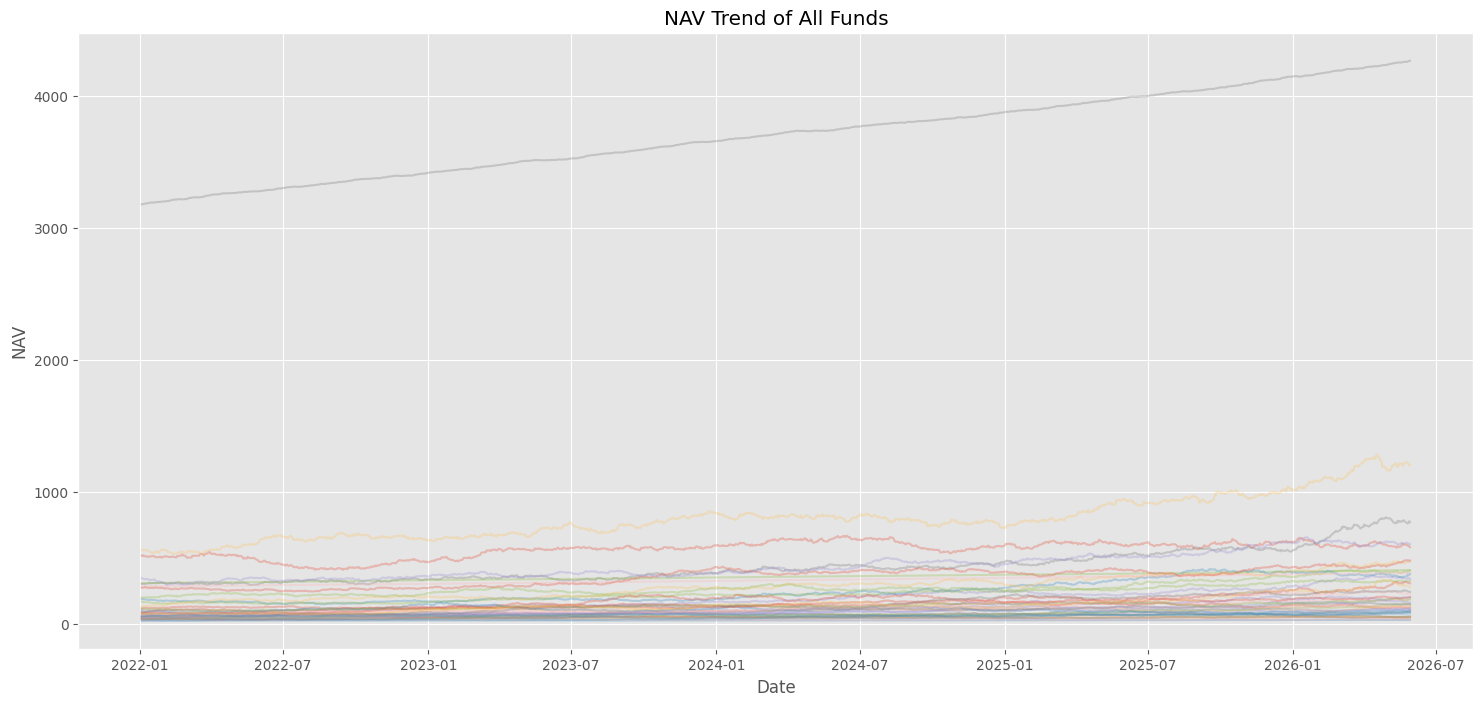

In [6]:
nav["date"] = pd.to_datetime(nav["date"])
plt.figure(figsize=(18,8))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"]==code]
    plt.plot(temp["date"], temp["nav"], alpha=0.3)

plt.title("NAV Trend of All Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

In [8]:
plt.savefig("../reports/nav_trend.png")

<Figure size 640x480 with 0 Axes>

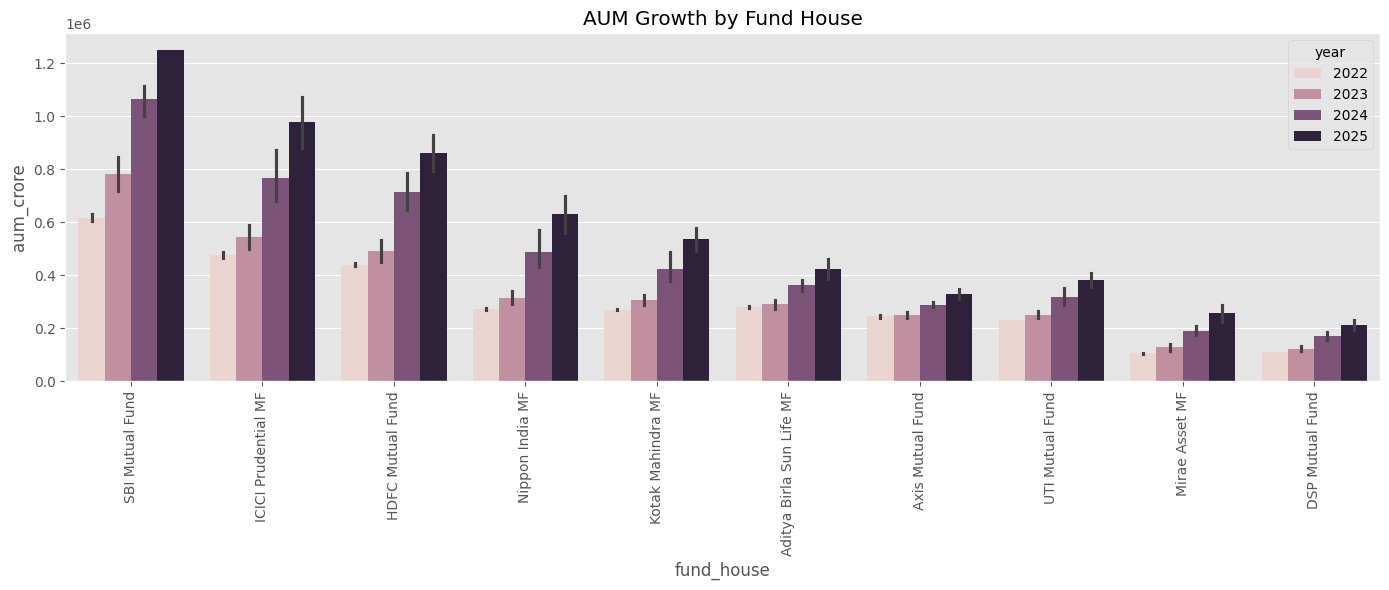

In [9]:
#Task 2 - AUM Growth

aum.head()
aum["year"] = pd.to_datetime(aum["date"]).dt.year
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House")
plt.tight_layout()

plt.show()

In [10]:
plt.savefig("../reports/aum_growth.png")

<Figure size 640x480 with 0 Axes>

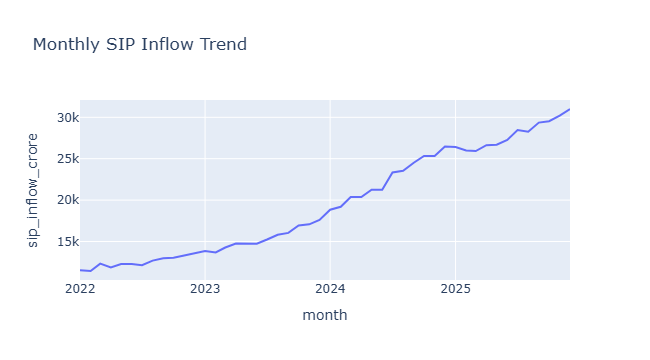

In [11]:
#Task 3 - SIP inflow trend

sip.columns
sip["month"]=pd.to_datetime(sip["month"])
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()

In [25]:
plt.savefig("../reports/sip_inflow_trend.png")

<Figure size 640x480 with 0 Axes>

In [12]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


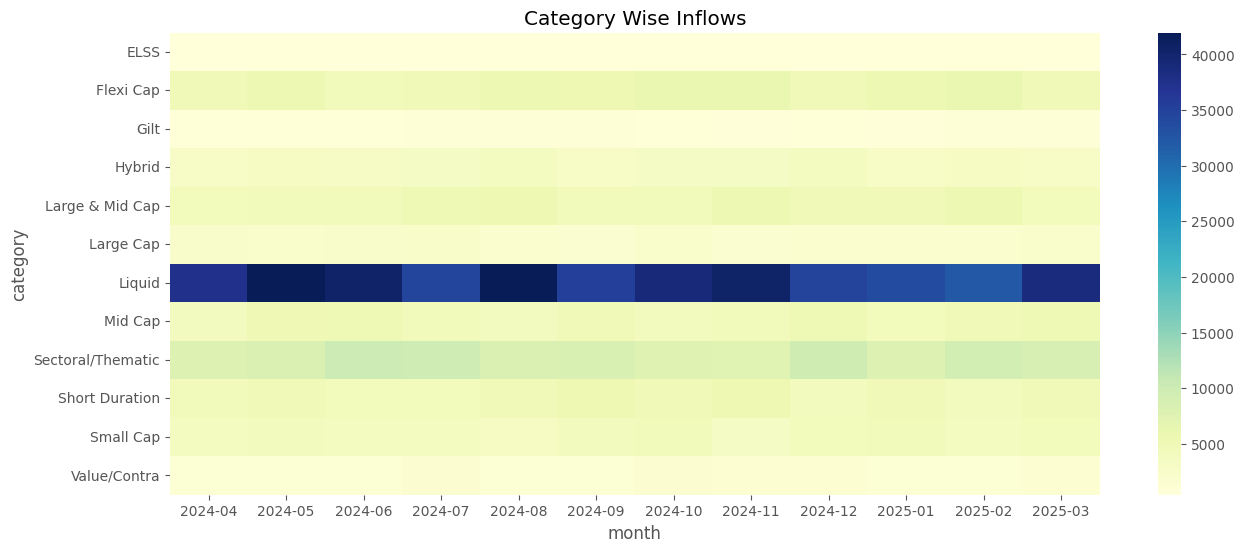

In [13]:
#Task 4 - Category inflow heatmap
category.columns
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)
plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Wise Inflows")
plt.show()

In [14]:
plt.savefig("../reports/category_heatmap.png")

<Figure size 640x480 with 0 Axes>

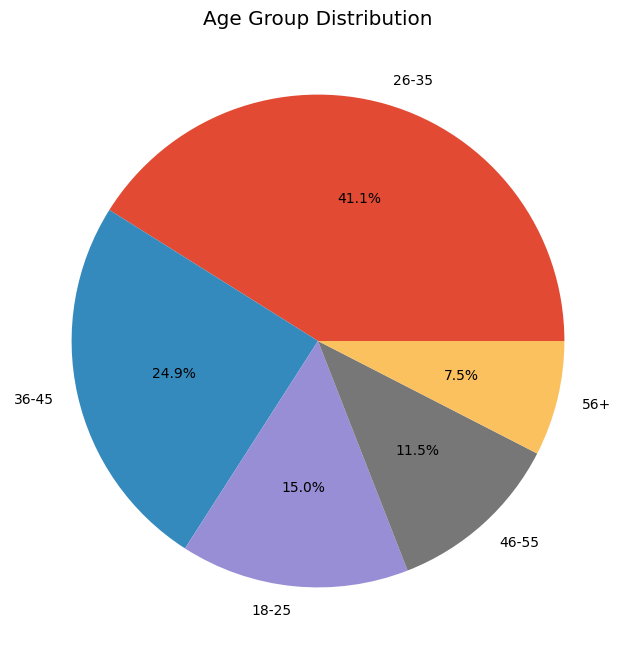

In [15]:
#Task 5 - Age group distribution
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

In [26]:
plt.savefig("../reports/Age_groupDistribution.png")

<Figure size 640x480 with 0 Axes>

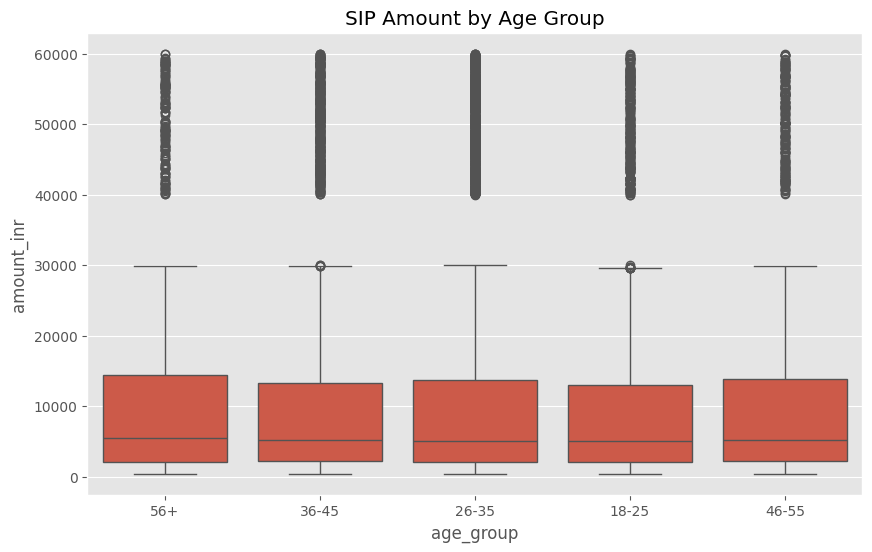

In [18]:
#Task 5 - SIP Amount Boxplot
sip_tx = transactions[
    transactions["transaction_type"]=="Sip"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_tx,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.show()

In [27]:
plt.savefig("../reports/Sip_amt_byAge.png")

<Figure size 640x480 with 0 Axes>

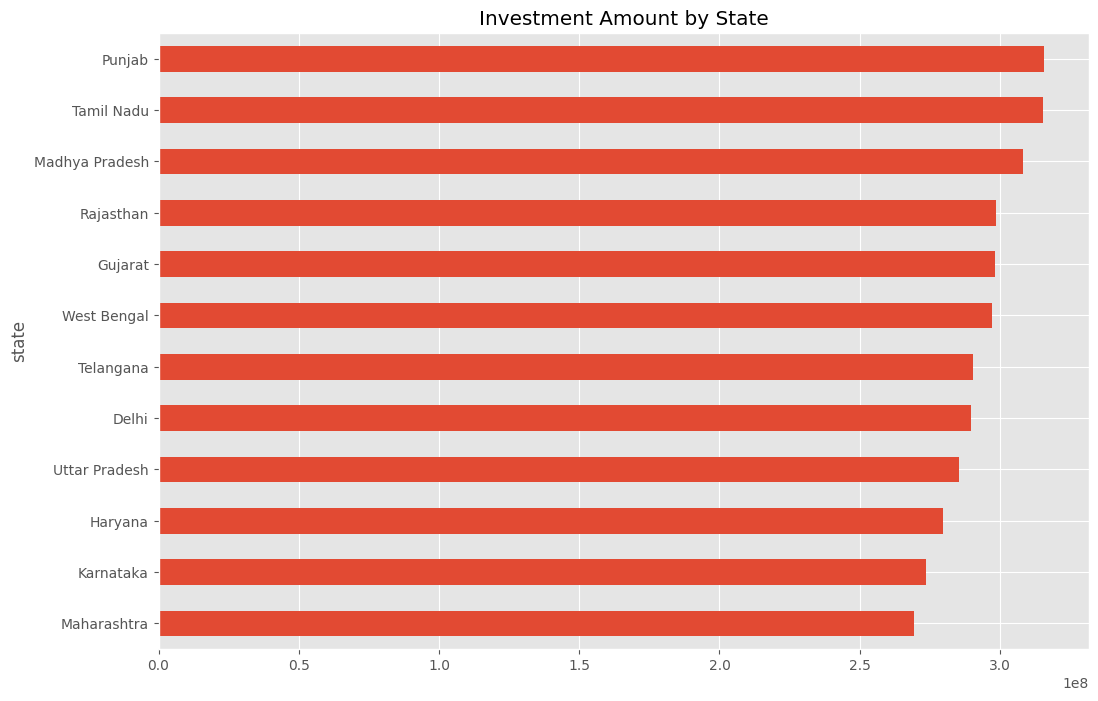

In [19]:
#Task 6 - SIP by state
state_amt = transactions.groupby("state")[
    "amount_inr"
].sum().sort_values()
plt.figure(figsize=(12,8))

state_amt.plot(kind="barh")

plt.title("Investment Amount by State")

plt.show()

In [28]:
plt.savefig("../reports/investment_byState.png")

<Figure size 640x480 with 0 Axes>

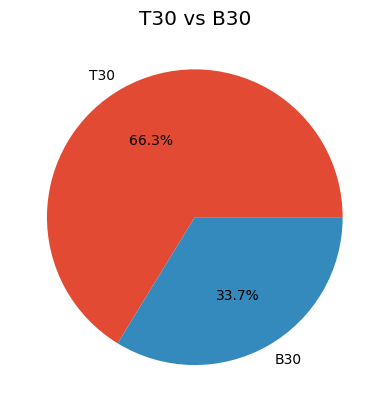

In [20]:
#Task 6 - T30 VS B30
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30")
plt.ylabel("")
plt.show()

In [29]:
plt.savefig("../reports/T30VSB30.png")

<Figure size 640x480 with 0 Axes>

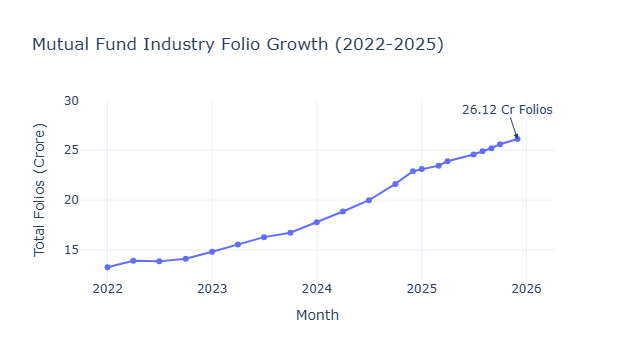

In [22]:
#Task 7 - FOLIO Growth
folio["month"] = pd.to_datetime(folio["month"])
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Mutual Fund Industry Folio Growth (2022-2025)",
    markers=True
)

fig.add_annotation(
    x=folio["month"].iloc[-1],
    y=folio["total_folios_crore"].iloc[-1],
    text=f"{folio['total_folios_crore'].iloc[-1]:.2f} Cr Folios",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    template="plotly_white"
)
fig.show()

In [30]:
plt.savefig("../reports/MFI_FOLIO_growth.png")

<Figure size 640x480 with 0 Axes>

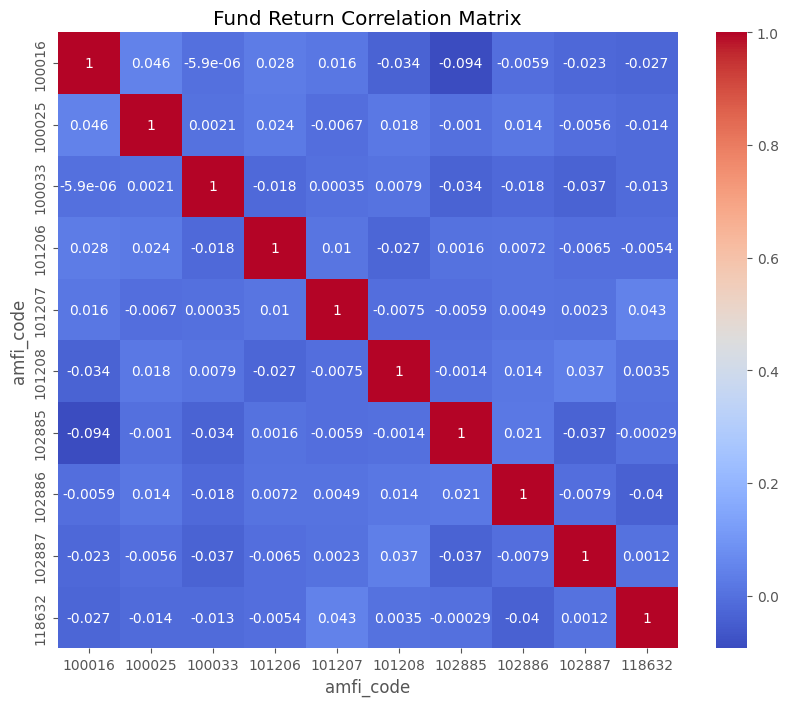

In [23]:
#Task 8 - correlation matrix
top10 = nav["amfi_code"].unique()[:10]

sample = nav[
    nav["amfi_code"].isin(top10)
]

pivot = sample.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")

plt.show()

In [31]:
plt.savefig("../reports/FundReturn_correlation.png")

<Figure size 640x480 with 0 Axes>

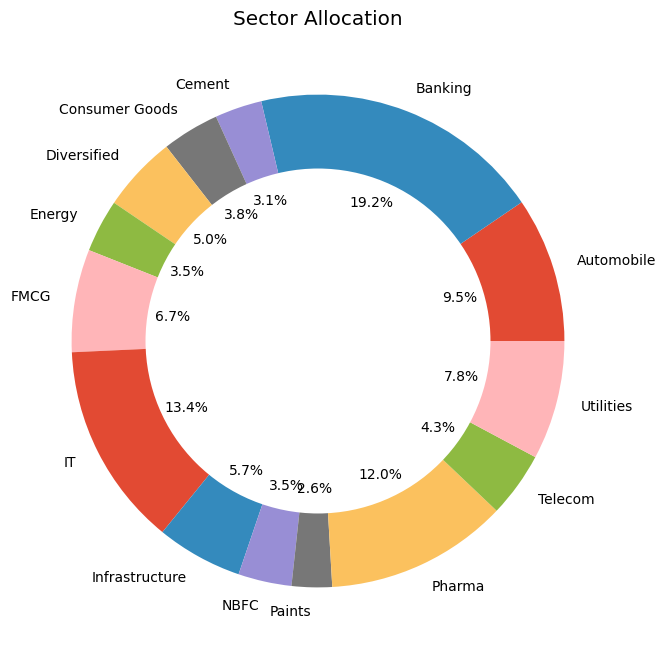

In [24]:
#Task 9 - sector distribution
portfolio.columns
sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre)

plt.title("Sector Allocation")
plt.show()

In [32]:
plt.savefig("../reports/SectorAllocation.png")

<Figure size 640x480 with 0 Axes>

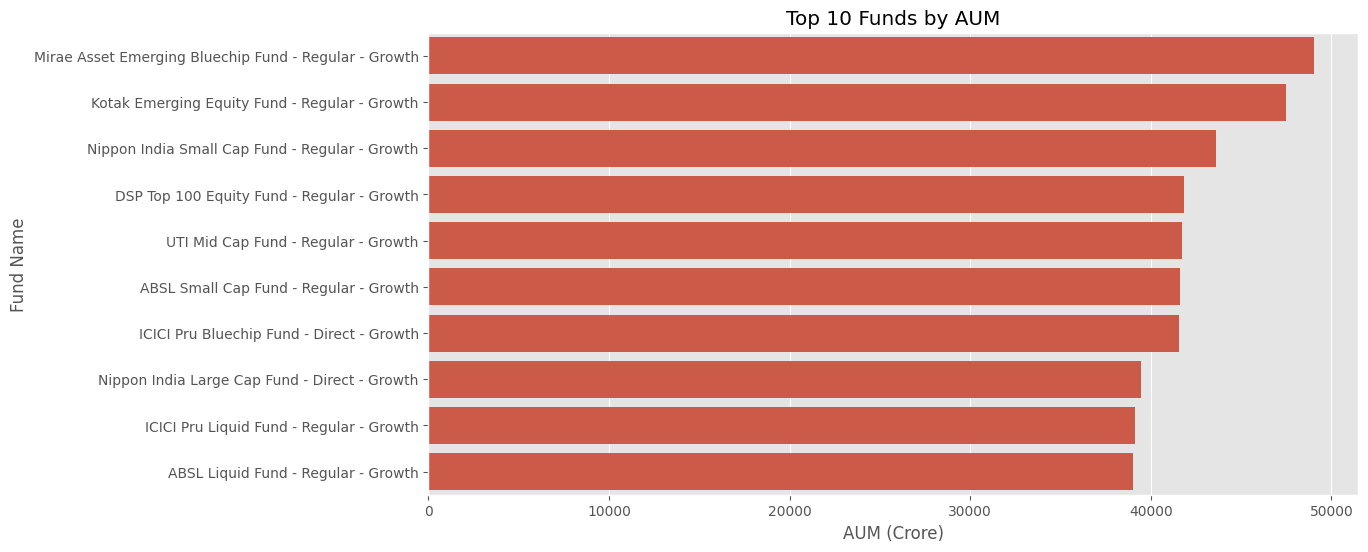

In [40]:
#Task 10 - Top 10 funds of AUM
import matplotlib.pyplot as plt
import seaborn as sns

top_funds = performance.sort_values(
    by="aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Fund Name")

plt.show()

In [41]:
plt.savefig("../reports/top10_funds_aum.png")

<Figure size 640x480 with 0 Axes>

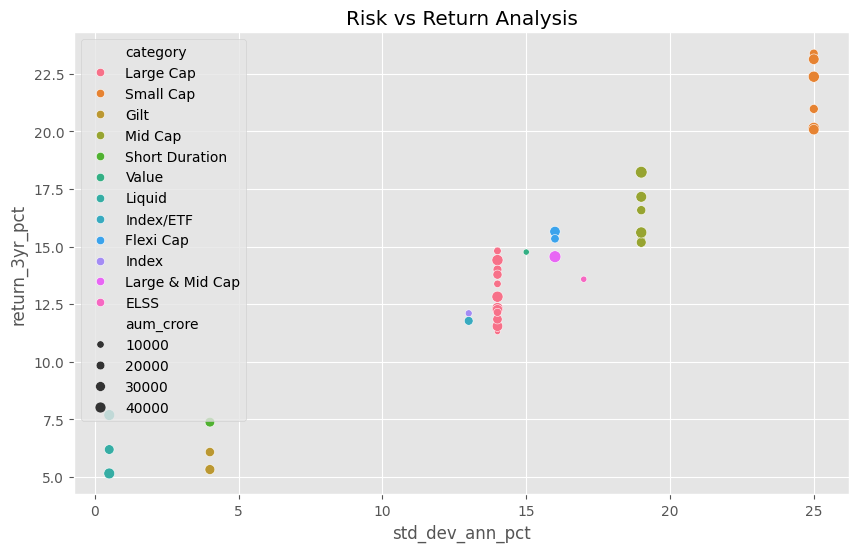

In [42]:
#Task 11 - Risk vs Return 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    size="aum_crore",
    hue="category"
)

plt.title("Risk vs Return Analysis")

plt.show()

In [43]:
plt.savefig("../reports/RiskVSReturn.png")

<Figure size 640x480 with 0 Axes>

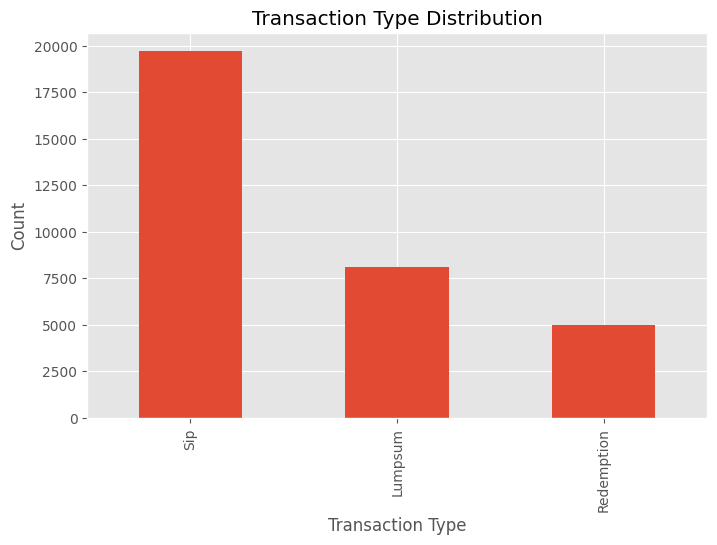

In [44]:
#Task 12 - Transaction Type
transactions["transaction_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

In [45]:
plt.savefig("../reports/Transaction_type.png")

<Figure size 640x480 with 0 Axes>

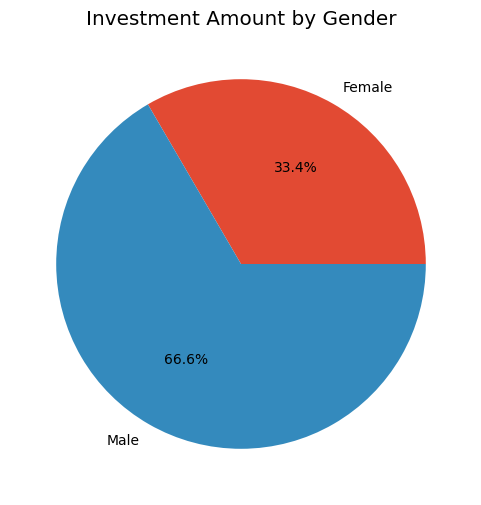

In [46]:
#Task 13 - Gender wise investment
gender_amt = transactions.groupby(
    "gender"
)["amount_inr"].sum()

plt.figure(figsize=(6,6))

gender_amt.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investment Amount by Gender")

plt.show()

In [47]:
plt.savefig("../reports/GenderWise.png")

<Figure size 640x480 with 0 Axes>

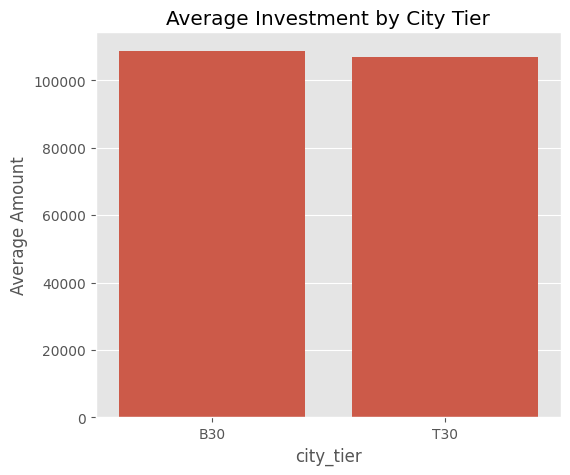

In [48]:
#Task 13 - Avg investement by City
city_tier_avg = transactions.groupby(
    "city_tier"
)["amount_inr"].mean()

plt.figure(figsize=(6,5))

sns.barplot(
    x=city_tier_avg.index,
    y=city_tier_avg.values
)

plt.title("Average Investment by City Tier")
plt.ylabel("Average Amount")

plt.show()

In [49]:
plt.savefig("../reports/Avg_investment_city.png")

<Figure size 640x480 with 0 Axes>

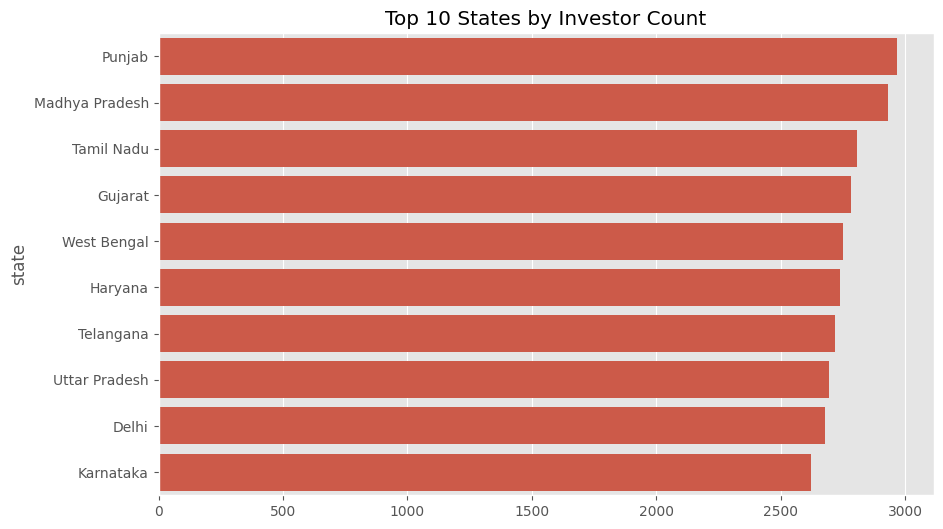

In [50]:
#Task 14 - Top states by investor counts
top_states = transactions["state"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Investor Count")

plt.show()

In [51]:
plt.savefig("../reports/TopState_investor.png")

<Figure size 640x480 with 0 Axes>

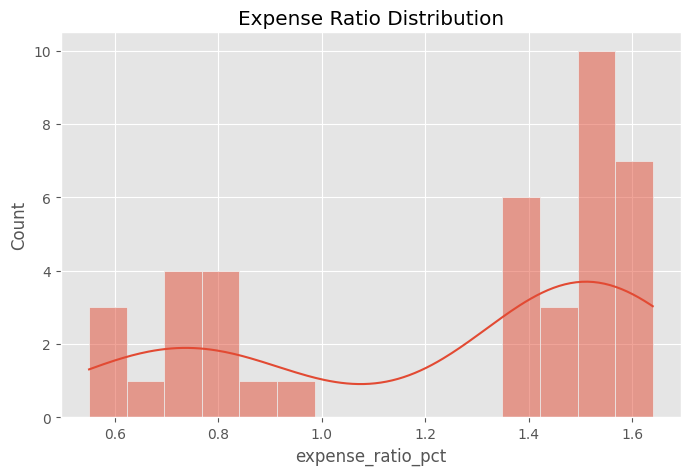

In [52]:
#Task 15 - Expense Ratio
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

In [53]:
plt.savefig("../reports/Expense_ratio.png")

<Figure size 640x480 with 0 Axes>